# 🏦 Banking Fraud Detection

| | |
|---|---|
| **Domain** | Finance / Banking |
| **Dataset** | CaixaBank Financial Transactions (2010s) |
| **Problem Type** | Binary Classification |
| **Target** | `is_fraud` (0 = Legitimate, 1 = Fraudulent) |
| **Tools** | Python, FLAML AutoML, SHAP, Power BI |


## Notebook 1 — Data Understanding & EDA
**DSAI 4103 Business Analytics**

This notebook loads all raw data files and performs exploratory data analysis on each file before any cleaning.

📊 Exploratory Data Analysis & Data Understanding

🔹 Purpose of this Notebook

This notebook focuses on understanding the dataset before any preprocessing or modeling. The goal is to explore the structure, quality, and characteristics of the data and identify potential issues that may affect later stages.

🔹 Business Problem

This project addresses the problem of detecting fraudulent transactions in banking data.

Fraud detection is difficult because:

Fraud cases are very rare
Transaction patterns are complex
Incorrect predictions can impact customers

The aim is to analyze transaction data and build a system that can identify fraudulent activity.

🔹 Objectives of Analysis

In this notebook, the following objectives are covered:

- Understand the structure of each dataset
- Analyze distributions of key variables
- Identify missing values and data quality issues
- Explore relationships between variables
- Examine class imbalance in the target variable

📁 Dataset Description

The dataset consists of multiple files representing different aspects of banking data:

- Transactions data → records of all transactions
- Cards data → details about cards
- Users data → customer information
- Fraud labels → indicates whether a transaction is fraud
- MCC codes → merchant category descriptions

These datasets are linked using IDs such as client_id, card_id, and transaction_id.

In [2]:
!pip install kaggle

# Downloading the Raw files from kaggle

In [3]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

# Create data folder
os.makedirs("data", exist_ok=True)

# Authenticate
api = KaggleApi()
api.authenticate()

# Download dataset
api.dataset_download_files(
    "computingvictor/transactions-fraud-datasets",
    path="data",
    unzip=True
)

print("Dataset downloaded to data/")

Dataset URL: https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets
Dataset downloaded to data/


### Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import re, json, pickle, os, warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
print('Libraries loaded')

Libraries loaded


Loads all 5 source files exactly as received. 

| File | Description |
|---|---|
| `transactions_data.csv` | All banking transactions 2010 - 2019 |
| `cards_data.csv` | Card details per customer |
| `users_data.csv` | Customer demographics |
| `mcc_codes.json` | Merchant category codes |
| `train_fraud_labels.json` | Fraud labels — target variable |


In [5]:
# Fix paths — for json files and load all the dataset
cards_bronze = pd.read_csv('data/cards_data.csv')
users_bronze = pd.read_csv('data/users_data.csv')

with open('data/mcc_codes.json', 'r') as f:
    mcc_bronze = json.load(f)

labels_raw = {}
with open('data/train_fraud_labels.json', 'r', errors='ignore') as f:
    content = f.read()
matches = re.findall(r'"(\d+)"\s*:\s*"(\w+)"', content)
for tid, label in matches:
    labels_raw[tid] = label

labels_bronze = pd.DataFrame(list(labels_raw.items()), columns=['id', 'is_fraud'])
labels_bronze['id'] = labels_bronze['id'].astype(int)
labels_bronze['is_fraud'] = (labels_bronze['is_fraud'] == 'Yes').astype(int)
print(f' Labels recovered: {len(labels_bronze):,}')
print(f'   Fraud rate: {labels_bronze["is_fraud"].mean()*100:.4f}%')

print('\nLoading full transactions file')
transactions_bronze = pd.read_csv('data/transactions_data.csv', dtype=str)

ram_used  = psutil.Process().memory_info().rss / 1024**3
ram_total = psutil.virtual_memory().total / 1024**3

print(f'\nBronze Layer Loaded')
print(f'{"="*50}')
print(f'  Transactions : {transactions_bronze.shape[0]:,} rows × {transactions_bronze.shape[1]} cols')
print(f'  Cards        : {cards_bronze.shape[0]:,} rows × {cards_bronze.shape[1]} cols')
print(f'  Users        : {users_bronze.shape[0]:,} rows × {users_bronze.shape[1]} cols')
print(f'  Fraud Labels : {labels_bronze.shape[0]:,} entries')
print(f'  MCC Codes    : {len(mcc_bronze)} merchant categories')
print(f'{"="*50}')
print(f' RAM used  : {ram_used:.1f}GB / {ram_total:.1f}GB')

 Labels recovered: 8,914,963
   Fraud rate: 0.1495%

Loading full transactions file

Bronze Layer Loaded
  Transactions : 13,305,915 rows × 12 cols
  Cards        : 6,146 rows × 13 cols
  Users        : 2,000 rows × 14 cols
  Fraud Labels : 8,914,963 entries
  MCC Codes    : 109 merchant categories
 RAM used  : 4.4GB / 15.8GB


In [6]:
mcc_bronze = pd.DataFrame(
    list(mcc_bronze.items()),
    columns=['mcc_code', 'mcc_description']
)

mcc_bronze['mcc_code'] = pd.to_numeric(mcc_bronze['mcc_code'], errors='coerce')

# EDA

### Data Understanding 

### Transaction file

In [7]:
print("TRANSACTIONS — RAW EDA")

print(f"\n1. SHAPE: {transactions_bronze.shape}")

print(f"\n2. COLUMN DATA TYPES:")
print(transactions_bronze.dtypes)

print(f"\n3. MISSING VALUES:")
missing = transactions_bronze.isnull().sum()
pct = (missing / len(transactions_bronze) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f"\n4. UNIQUE VALUES PER COLUMN:")
for col in transactions_bronze.columns:
    print(f"   {col}: {transactions_bronze[col].nunique():,} unique values")

print(f"\n5. SAMPLE ROWS:")
display(transactions_bronze.head(3))

print(f"\n6. VALUE COUNTS — use_chip:")
print(transactions_bronze['use_chip'].value_counts())

print(f"\n7. AMOUNT SAMPLE (raw):")
print(transactions_bronze['amount'].describe())

TRANSACTIONS — RAW EDA

1. SHAPE: (13305915, 12)

2. COLUMN DATA TYPES:
id                object
date              object
client_id         object
card_id           object
amount            object
use_chip          object
merchant_id       object
merchant_city     object
merchant_state    object
zip               object
mcc               object
errors            object
dtype: object

3. MISSING VALUES:
                Missing Count  Missing %
merchant_state        1563700      11.75
zip                   1652706      12.42
errors               13094522      98.41

4. UNIQUE VALUES PER COLUMN:
   id: 13,305,915 unique values
   date: 4,136,496 unique values
   client_id: 1,219 unique values
   card_id: 4,071 unique values
   amount: 81,161 unique values
   use_chip: 3 unique values
   merchant_id: 74,831 unique values
   merchant_city: 12,492 unique values
   merchant_state: 199 unique values
   zip: 25,256 unique values
   mcc: 109 unique values
   errors: 22 unique values

5. SAMPLE R

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN



6. VALUE COUNTS — use_chip:
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: use_chip, dtype: int64

7. AMOUNT SAMPLE (raw):
count     13305915
unique       81161
top         $80.00
freq        132115
Name: amount, dtype: object


### Cards file

In [8]:
print("CARDS — RAW EDA")
print(f"\n1. SHAPE: {cards_bronze.shape}")

print(f"\n2. COLUMN DATA TYPES:")
print(cards_bronze.dtypes)

print(f"\n3. MISSING VALUES:")
missing = cards_bronze.isnull().sum()
pct = (missing / len(cards_bronze) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))

print(f"\n4. UNIQUE VALUES PER COLUMN:")
for col in cards_bronze.columns:
    print(f"   {col}: {cards_bronze[col].nunique():,} unique values")

print(f"\n5. SAMPLE ROWS:")
display(cards_bronze.head(3))

print(f"\n6. KEY VALUE COUNTS:")
print("\ncard_brand:\n", cards_bronze['card_brand'].value_counts())
print("\ncard_type:\n", cards_bronze['card_type'].value_counts())
print("\nhas_chip:\n", cards_bronze['has_chip'].value_counts())
print("\ncard_on_dark_web:\n", cards_bronze['card_on_dark_web'].value_counts())

CARDS — RAW EDA

1. SHAPE: (6146, 13)

2. COLUMN DATA TYPES:
id                        int64
client_id                 int64
card_brand               object
card_type                object
card_number               int64
expires                  object
cvv                       int64
has_chip                 object
num_cards_issued          int64
credit_limit             object
acct_open_date           object
year_pin_last_changed     int64
card_on_dark_web         object
dtype: object

3. MISSING VALUES:
                       Missing Count  Missing %
id                                 0        0.0
client_id                          0        0.0
card_brand                         0        0.0
card_type                          0        0.0
card_number                        0        0.0
expires                            0        0.0
cvv                                0        0.0
has_chip                           0        0.0
num_cards_issued                   0        0.0
credit_li

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No



6. KEY VALUE COUNTS:

card_brand:
 Mastercard    3209
Visa          2326
Amex           402
Discover       209
Name: card_brand, dtype: int64

card_type:
 Debit              3511
Credit             2057
Debit (Prepaid)     578
Name: card_type, dtype: int64

has_chip:
 YES    5500
NO      646
Name: has_chip, dtype: int64

card_on_dark_web:
 No    6146
Name: card_on_dark_web, dtype: int64


### Users File

In [9]:
print("USERS — RAW EDA")
print(f"\n1. SHAPE: {users_bronze.shape}")

print(f"\n2. COLUMN DATA TYPES:")
print(users_bronze.dtypes)

print(f"\n3. MISSING VALUES:")
missing = users_bronze.isnull().sum()
pct = (missing / len(users_bronze) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))

print(f"\n4. UNIQUE VALUES PER COLUMN:")
for col in users_bronze.columns:
    print(f"   {col}: {users_bronze[col].nunique():,} unique values")

print(f"\n5. SAMPLE ROWS:")
display(users_bronze.head(3))

print(f"\n6. KEY DISTRIBUTIONS:")
print("\ngender:\n", users_bronze['gender'].value_counts())
print("\nage range:", users_bronze['current_age'].min(),
      "to", users_bronze['current_age'].max())
print("\ncredit_score range:", users_bronze['credit_score'].min(),
      "to", users_bronze['credit_score'].max())

USERS — RAW EDA

1. SHAPE: (2000, 14)

2. COLUMN DATA TYPES:
id                     int64
current_age            int64
retirement_age         int64
birth_year             int64
birth_month            int64
gender                object
address               object
latitude             float64
longitude            float64
per_capita_income     object
yearly_income         object
total_debt            object
credit_score           int64
num_credit_cards       int64
dtype: object

3. MISSING VALUES:
                   Missing Count  Missing %
id                             0        0.0
current_age                    0        0.0
retirement_age                 0        0.0
birth_year                     0        0.0
birth_month                    0        0.0
gender                         0        0.0
address                        0        0.0
latitude                       0        0.0
longitude                      0        0.0
per_capita_income              0        0.0
yearly_income  

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5



6. KEY DISTRIBUTIONS:

gender:
 Female    1016
Male       984
Name: gender, dtype: int64

age range: 18 to 101

credit_score range: 480 to 850


### Fraud Labels data (train_fraud_labels.json)

In [10]:
print("FRAUD LABELS — RAW EDA")

print(f"\n1. SHAPE: {labels_bronze.shape}")
print(f"\n2. DATA TYPES:\n{labels_bronze.dtypes}")

# Missing values
print(f"\n3. MISSING VALUES:")
print(labels_bronze.isnull().sum())

# Duplicates
print(f"\n4. DUPLICATE IDs: {labels_bronze['id'].duplicated().sum():,}")

# Target distribution
print(f"\n5. TARGET DISTRIBUTION:")
print(labels_bronze['is_fraud'].value_counts())
print(f"\nFraud Rate : {labels_bronze['is_fraud'].mean()*100:.4f}%")
print(f"Imbalance Ratio: 1 fraud per {int((labels_bronze['is_fraud']==0).sum() / labels_bronze['is_fraud'].sum()):,} legitimate")


FRAUD LABELS — RAW EDA

1. SHAPE: (8914963, 2)

2. DATA TYPES:
id          int32
is_fraud    int32
dtype: object

3. MISSING VALUES:
id          0
is_fraud    0
dtype: int64



4. DUPLICATE IDs: 0

5. TARGET DISTRIBUTION:
0    8901631
1      13332
Name: is_fraud, dtype: int64

Fraud Rate : 0.1495%
Imbalance Ratio: 1 fraud per 667 legitimate


In [11]:

# Check label coverage vs transactions
print(f"\n6. LABEL COVERAGE:")
print(f"   Total transactions    : {len(transactions_bronze):,}")
print(f"   Labeled transactions  : {len(labels_bronze):,}")
print(f"   Unlabeled transactions: {len(transactions_bronze) - len(labels_bronze):,}")
print(f"   Coverage              : {len(labels_bronze)/len(transactions_bronze)*100:.2f}%")

# Check ID overlap
trans_ids = set(transactions_bronze['id'].astype(int))
label_ids = set(labels_bronze['id'])
print(f"\n7. ID OVERLAP:")
print(f"   Transaction IDs     : {len(trans_ids):,}")
print(f"   Label IDs           : {len(label_ids):,}")
print(f"   IDs in both         : {len(trans_ids & label_ids):,}")
print(f"   Labels with no match: {len(label_ids - trans_ids):,}")


6. LABEL COVERAGE:
   Total transactions    : 13,305,915
   Labeled transactions  : 8,914,963
   Unlabeled transactions: 4,390,952
   Coverage              : 67.00%

7. ID OVERLAP:
   Transaction IDs     : 13,305,915
   Label IDs           : 8,914,963
   IDs in both         : 8,914,963
   Labels with no match: 0


# mcc_codes

In [12]:
print("MCC — RAW EDA")

# 1. SHAPE
print(f"\n1. SHAPE: {mcc_bronze.shape}")

# 2. COLUMN DATA TYPES
print(f"\n2. COLUMN DATA TYPES:")
print(mcc_bronze.dtypes)

# 3. MISSING VALUES
print(f"\n3. MISSING VALUES:")
missing = mcc_bronze.isnull().sum()
pct = (missing / len(mcc_bronze) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': pct}))

# 4. UNIQUE VALUES
print(f"\n4. UNIQUE VALUES PER COLUMN:")
for col in mcc_bronze.columns:
    print(f"   {col}: {mcc_bronze[col].nunique():,} unique values")

# 5. SAMPLE ROWS
print(f"\n5. SAMPLE ROWS:")
display(mcc_bronze.head(5))

# 6. DESCRIPTION LENGTH (optional insight)
print(f"\n6. DESCRIPTION LENGTH:")
print("Min length:", mcc_bronze['mcc_description'].str.len().min())
print("Max length:", mcc_bronze['mcc_description'].str.len().max())

MCC — RAW EDA

1. SHAPE: (109, 2)

2. COLUMN DATA TYPES:
mcc_code            int64
mcc_description    object
dtype: object

3. MISSING VALUES:
                 Missing Count  Missing %
mcc_code                     0        0.0
mcc_description              0        0.0

4. UNIQUE VALUES PER COLUMN:
   mcc_code: 109 unique values
   mcc_description: 108 unique values

5. SAMPLE ROWS:


,mcc_code,mcc_description
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees



6. DESCRIPTION LENGTH:
Min length: 8
Max length: 51


# Visuals

# Transaction

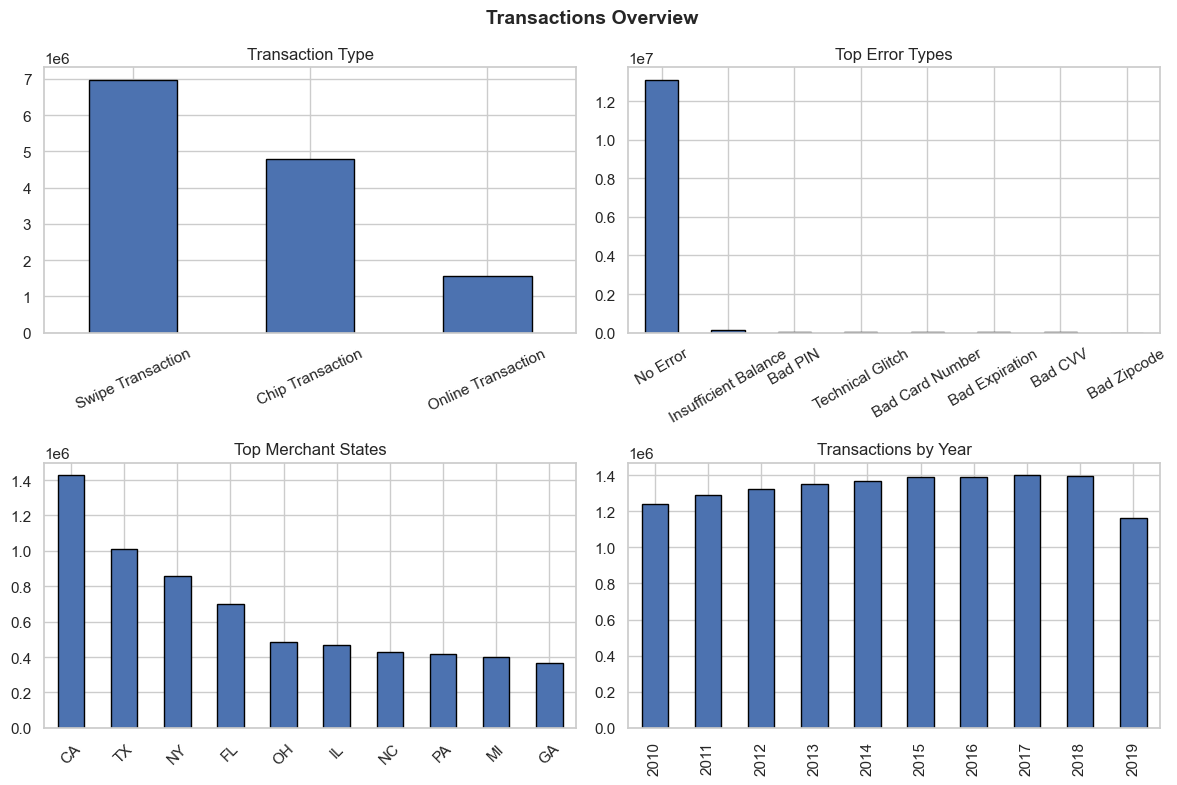

In [13]:
# ============================
# TRANSACTIONS EDA
# ============================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Transactions Overview', fontsize=14, fontweight='bold')

# Transaction type
transactions_bronze['use_chip'].value_counts().plot(
    kind='bar', ax=axes[0,0], edgecolor='black')
axes[0,0].set_title('Transaction Type')
axes[0,0].tick_params(axis='x', rotation=25)

# Errors
transactions_bronze['errors'].fillna('No Error').value_counts().head(8).plot(
    kind='bar', ax=axes[0,1], edgecolor='black')
axes[0,1].set_title('Top Error Types')
axes[0,1].tick_params(axis='x', rotation=30)

# Merchant state
transactions_bronze['merchant_state'].value_counts().head(10).plot(
    kind='bar', ax=axes[1,0], edgecolor='black')
axes[1,0].set_title('Top Merchant States')
axes[1,0].tick_params(axis='x', rotation=45)

# Year
pd.to_datetime(transactions_bronze['date'], errors='coerce').dt.year.value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('Transactions by Year')

plt.tight_layout()
plt.show()

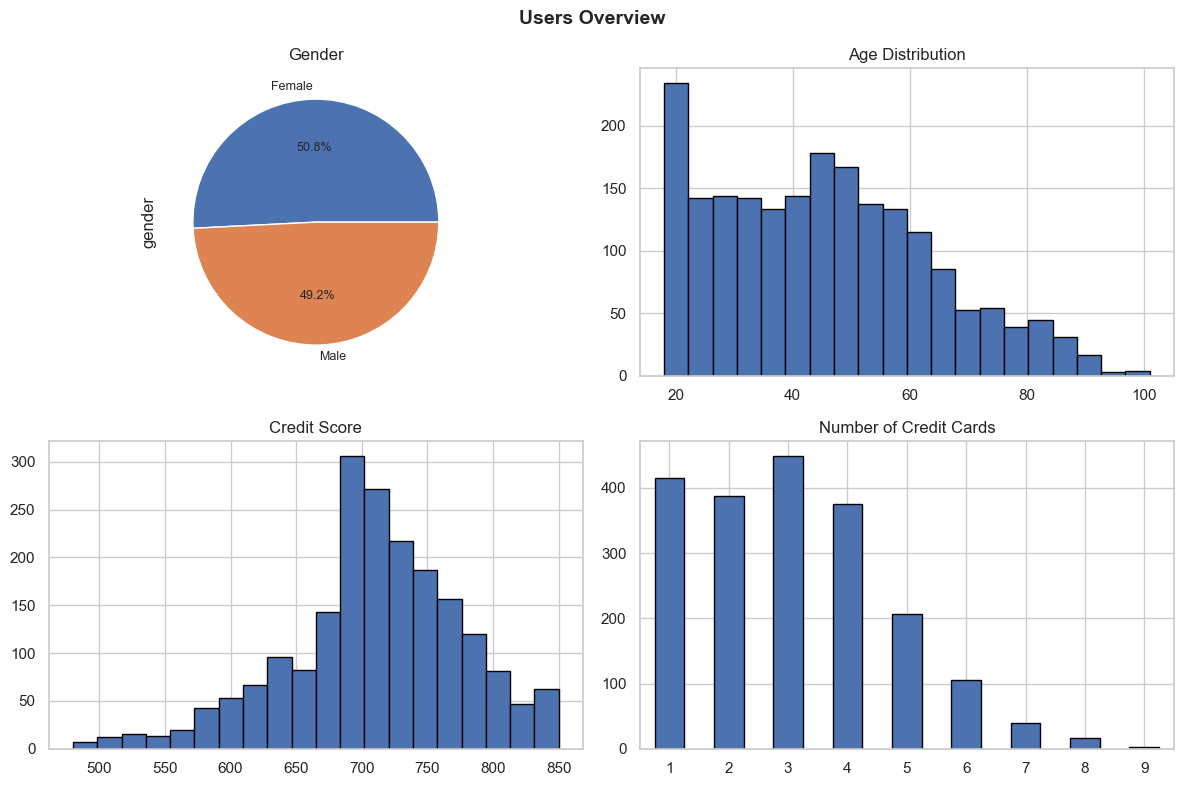

In [14]:
# USERS EDA

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Users Overview', fontsize=14, fontweight='bold')

# Gender
users_bronze['gender'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,0], textprops={'fontsize': 9})
axes[0,0].set_title('Gender')

# Age
axes[0,1].hist(users_bronze['current_age'], bins=20, edgecolor='black')
axes[0,1].set_title('Age Distribution')

# Credit score
axes[1,0].hist(users_bronze['credit_score'], bins=20, edgecolor='black')
axes[1,0].set_title('Credit Score')

# Cards
users_bronze['num_credit_cards'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('Number of Credit Cards')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Total labels: 8,914,963

Class Distribution:
0    8901631
1      13332
Name: is_fraud, dtype: int64

Fraud Rate: 0.1495%


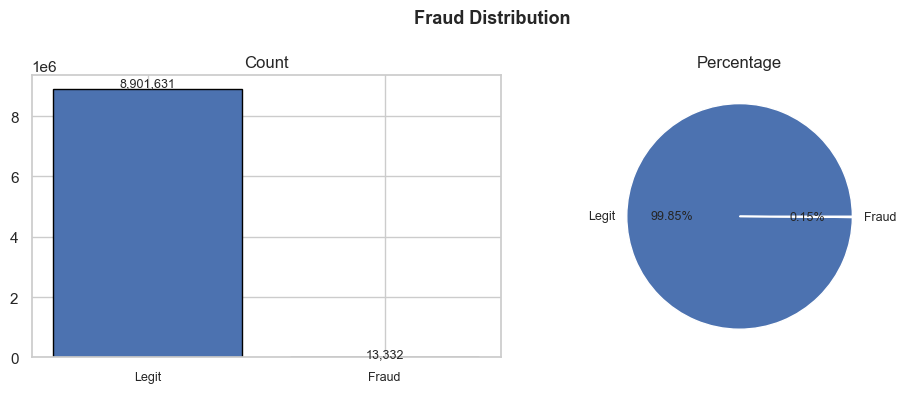

In [15]:
# ============================
# FRAUD LABELS EDA
# ============================

print(f"Total labels: {len(labels_bronze):,}")
print("\nClass Distribution:")
print(labels_bronze['is_fraud'].value_counts())
print(f"\nFraud Rate: {labels_bronze['is_fraud'].mean()*100:.4f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Fraud Distribution', fontsize=13, fontweight='bold')

counts = labels_bronze['is_fraud'].value_counts()

# Bar chart
axes[0].bar(['Legit', 'Fraud'], counts.values, edgecolor='black')
axes[0].set_title('Count')
axes[0].tick_params(axis='x', labelsize=9)

# Add labels (smaller + controlled)
for i, v in enumerate(counts.values):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(counts.values,
            labels=['Legit', 'Fraud'],
            autopct='%1.2f%%',
            textprops={'fontsize': 9})
axes[1].set_title('Percentage')

plt.tight_layout()
plt.show()

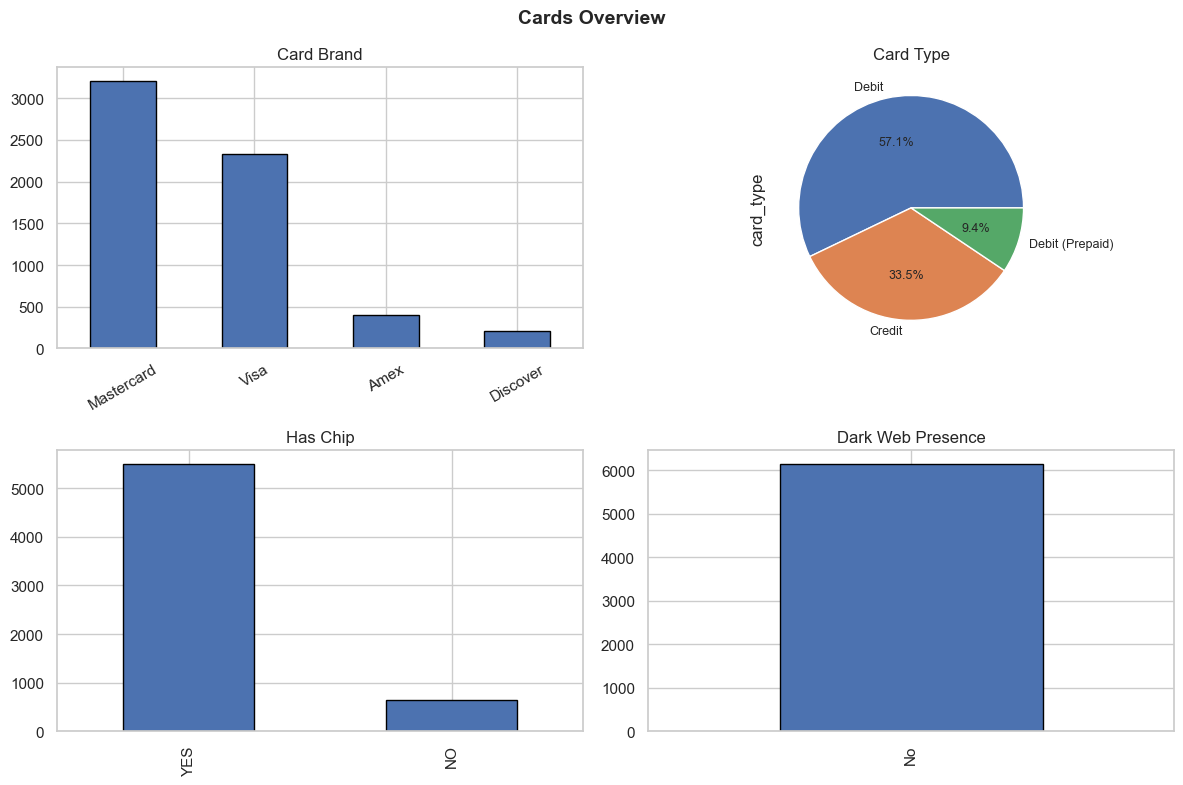

In [16]:
# ============================
# CARDS EDA
# ============================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Cards Overview', fontsize=14, fontweight='bold')

cards_bronze['card_brand'].value_counts().plot(
    kind='bar', ax=axes[0,0], edgecolor='black')
axes[0,0].set_title('Card Brand')
axes[0,0].tick_params(axis='x', rotation=30)

cards_bronze['card_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[0,1], textprops={'fontsize': 9})
axes[0,1].set_title('Card Type')

cards_bronze['has_chip'].value_counts().plot(
    kind='bar', ax=axes[1,0], edgecolor='black')
axes[1,0].set_title('Has Chip')

cards_bronze['card_on_dark_web'].value_counts().plot(
    kind='bar', ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('Dark Web Presence')

plt.tight_layout()
plt.show()

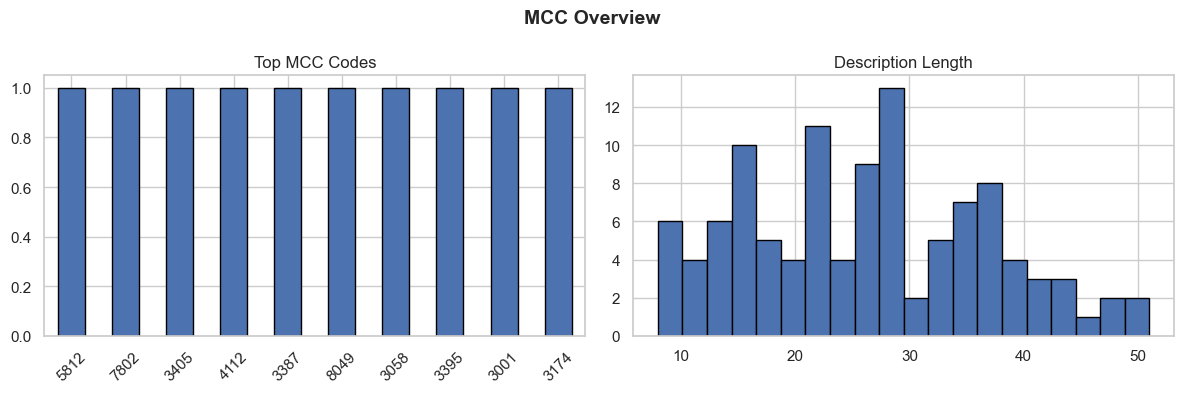

In [17]:
# ============================
# MCC EDA
# ============================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MCC Overview', fontsize=14, fontweight='bold')

# Top MCC codes
mcc_bronze['mcc_code'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Top MCC Codes')
axes[0].tick_params(axis='x', rotation=45)

# Description length
mcc_bronze['mcc_description'].str.len().hist(
    bins=20, ax=axes[1], edgecolor='black')
axes[1].set_title('Description Length')

plt.tight_layout()
plt.show()

# Statistical Summary

In [18]:
# ============================
# STATISTICAL SUMMARY
# ============================

print("="*60)
print("STATISTICAL SUMMARY — ALL DATASETS")
print("="*60)

datasets = {
    "Transactions": transactions_bronze,
    "Users": users_bronze,
    "Cards": cards_bronze,
    "MCC": mcc_bronze,
    "Fraud Labels": labels_bronze
}

for name, df in datasets.items():
    print(f"\n🔹 {name.upper()} DATASET")
    print("-"*50)

    # Shape
    print(f"Shape: {df.shape}")

    # Numerical summary
    print("\nNumerical Summary:")
    display(df.describe())

    # Categorical Summary
    cat_cols = df.select_dtypes(include='object').columns

    if len(cat_cols) > 0:
        print("\nCategorical Summary:")
        display(df[cat_cols].describe())
    else:
        print("\nCategorical Summary: None")

STATISTICAL SUMMARY — ALL DATASETS

🔹 TRANSACTIONS DATASET
--------------------------------------------------
Shape: (13305915, 12)

Numerical Summary:


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
count,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,11742215,11653209,13305915,211393
unique,13305915,4136496,1219,4071,81161,3,74831,12492,199,25256,109,22
top,7475327,2011-06-09 12:46:00,1098,4938,$80.00,Swipe Transaction,59935,ONLINE,CA,98516.0,5411,Insufficient Balance
freq,1,18,48479,31552,132115,6967185,610053,1563700,1427087,36753,1592584,130902



Categorical Summary:


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
count,13305915,13305915,13305915,13305915,13305915,13305915,13305915,13305915,11742215,11653209,13305915,211393
unique,13305915,4136496,1219,4071,81161,3,74831,12492,199,25256,109,22
top,7475327,2011-06-09 12:46:00,1098,4938,$80.00,Swipe Transaction,59935,ONLINE,CA,98516.0,5411,Insufficient Balance
freq,1,18,48479,31552,132115,6967185,610053,1563700,1427087,36753,1592584,130902



🔹 USERS DATASET
--------------------------------------------------
Shape: (2000, 14)

Numerical Summary:


...


Categorical Summary:


,mcc_description
count,109
unique,108
top,Passenger Railways
freq,2



🔹 FRAUD LABELS DATASET
--------------------------------------------------
Shape: (8914963, 2)

Numerical Summary:


,id,is_fraud
count,8.914963e+06,8.914963e+06
mean,1.558473e+07,1.495463e-03
std,4.703991e+06,3.864230e-02
min,7.475327e+06,0.000000e+00
25%,1.150786e+07,0.000000e+00
50%,1.557140e+07,0.000000e+00
75%,1.965387e+07,0.000000e+00
max,2.376187e+07,1.000000e+00



Categorical Summary: None


In [23]:
# ============================
# SAVE BRONZE DATA
# ============================

transactions_bronze.to_parquet('bronze_transactions.parquet', index=False)
labels_bronze.to_parquet('bronze_labels.parquet', index=False)

cards_bronze.to_csv('bronze_cards.csv', index=False)
users_bronze.to_csv('bronze_users.csv', index=False)
mcc_bronze.to_csv('bronze_mcc.csv', index=False)

print("Raw files saved successfully")

Raw files saved successfully


##### More EDA in done after merging all the table to see the realtionship between target and features

## Key Insights 

- The dataset is very large, with over 13 million transactions, making it suitable for building a robust model 

- Fraud cases are extremely rare (~0.15%), indicating a highly imbalanced dataset (about 1 fraud per 667 transactions)

- A significant portion of transactions (~33%) do not have fraud labels, meaning only partial data can be used for supervised learning 

- The `errors` column has very high missing values (~98%), suggesting it may have limited usefulness or require special handling 

- Transaction data is dominated by swipe transactions, followed by chip and online transactions, indicating different usage patterns 

- The amount column is stored as text (with currency symbols), requiring cleaning before numerical analysis  

- Customer data shows a wide age range (18 to 101) and varied credit scores (480 to 850), indicating diverse user profiles 

- Card data shows most cards have chips and the majority are debit cards, which may influence transaction behavior  

- No missing values were found in users and cards datasets, indicating good data quality for these tables 

- All fraud labels correctly match transaction IDs, confirming consistency between datasets 
